In [2]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CONTINUUM_WINDOWS

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d
from datetime import datetime
from scipy.signal import argrelmin, argrelmax
from ast import literal_eval

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import json
import os

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"
hamann_desi_spectra_path = "data/local/hamann_desi_spectra.json"
relevant_erq_data_path = "data/relevant_erq_data.csv"

pd.options.mode.chained_assignment = None

### load data

In [3]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 47 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sdss_name    97 non-null     object 
 1   Plate        97 non-null     int32  
 2   MJD          97 non-null     int32  
 3   FiberID      97 non-null     int32  
 4   ThingID      97 non-null     int32  
 5   z_dr12       97 non-null     float64
 6   i            97 non-null     float64
 7   i_err        97 non-null     float64
 8   W3           97 non-null     float64
 9   W3_snr       97 non-null     float64
 10  cc_flags     97 non-null     object 
 11  bal_flag_vi  97 non-null     int32  
 12  f1450        97 non-null     float64
 13  alpha_civ    97 non-null     float64
 14  alpha_nv     97 non-null     float64
 15  alpha_all    97 non-null     float64
 16  alphae_all   97 non-null     float64
 17  alpha_allc   97 non-null     float64
 18  alphae_allc  97 non-null     float64
 19  rew       

In [4]:
# client = SparclClient()

# idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df

### measure lines

In [5]:
# spectra_df.to_json(hamann_desi_spectra_path)

spectra_df = pd.read_json(hamann_desi_spectra_path)

In [6]:
stats_half = hamann_erq[['sdss_name', 'rew', 'fwhm', 'kt80', 'targetid']].copy()

spectra_df["targetid"] = spectra_df["targetid"].astype("string")

data = spectra_df.merge(stats_half,on="targetid")

data["my_fwhm"] = None
data["my_rew"] = None
data["fit_rew"] = None
data["my_kt80"] = None

In [7]:
def get_absorption_interval(lam, flux, ivar):
    mask = (lam > 1450) & (lam < 1650)

    lam, flux, ivar = lam[mask], flux[mask], ivar[mask]
    flux_conv = convolve(flux, Gaussian1DKernel(3))

    noise = np.where(ivar > 0, 1.0 / np.sqrt(np.maximum(ivar, 1e-30)), np.inf)

    mins = argrelmin(flux_conv)
    maxs = argrelmax(flux_conv)
    extrema_idxs = sorted(list(mins[0])+list((maxs[0])))
    mins_list = [(lam[i],flux_conv[i],noise[i],0) for i in mins[0]]
    maxs_list = [(lam[i],flux_conv[i],noise[i],1) for i in maxs[0]]
    extrema = pd.DataFrame(sorted(mins_list + maxs_list),columns=["lam","flux_conv","noise","max_bool"])
    extrema["flux_diff_backward"] = extrema["flux_conv"].diff().abs()
    extrema["flux_diff_forward"] = extrema["flux_conv"].diff(-1).abs()
    extrema["more_than_noise"] = (extrema["flux_diff_backward"] > 1.5*extrema["noise"]) & (extrema["flux_diff_forward"] > 1.5*extrema["noise"])
    extrema["overall_max_bool"] = extrema["flux_conv"] == extrema["flux_conv"].max()

    query = extrema.query("more_than_noise == 1 and max_bool == 0")

    if len(query) > 0:
        idx = query.index
        try:
            if extrema["overall_max_bool"][idx-1].squeeze() == True or extrema["overall_max_bool"][idx+1].squeeze() == True:

                lower = extrema["lam"][idx-1].squeeze()
                upper = extrema["lam"][idx+1].squeeze()
                five_percent = (upper - lower) * 0.05  # um nen puffer zu haben quasi

                absorption_interval = (lower+five_percent, upper-five_percent)

                return absorption_interval

        except ValueError:
            print("ValueError in get_absorption_interval()")

    return None

In [8]:
def get_ci(lam,profile,interval=0.99):
    cutoff = (1-interval)/2
    
    cumsum = np.cumsum(profile)
    cumsum /= np.max(cumsum)
    
    lower_idx = np.searchsorted(cumsum,cutoff)
    upper_idx = np.searchsorted(cumsum,1-cutoff,side="left")

    return (lam[lower_idx], lam[upper_idx])

In [9]:
def sanity_tests(idx):
    lam = np.array(data["wavelength"][idx])
    flux = np.array(data["flux"][idx])
    ivar = np.array(data["ivar"][idx])
    z = data["redshift"][idx]

    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    # flux = convolve(flux, Gaussian1DKernel(1))

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)

    if rejected:
        print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    # flux_clean = convolve(flux_clean, Box1DKernel(5))

    flux_sub = flux_clean - continuum if not rejected else None

    absorption_interval = get_absorption_interval(lam,flux,ivar)

    if absorption_interval is not None:
        bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
    else:
        bal_mask = None
    # bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    if accept_two:
        # sigma_w = result2.params["sigma_w"].value
        # sigma_c = result2.params["sigma_c"].value
        # mu_w = result2.params["cen_w"].value
        # mu_c = result2.params["cen_c"].value

        # lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
        # upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
        # ci = (lower,upper)

        profile = profile2
    else:
        # mu = result1.params["center"].value
        # sigma = result1.params["sigma"].value
        # ci = (mu-3*sigma, mu+3*sigma)
        
        profile = profile1

    # ci = (mu-2*sigma, mu+2*sigma)
    ci = get_ci(lam,profile)

    plot_mask = (lam >= 1400) & (lam <= 1700)
    continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

    # flux_sub = convolve(flux_sub, Box1DKernel(7))

    if absorption_interval is not None:
        line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
    else:
        line_stats, win = measure_line(lam, profile, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )

    out_str = f'''
                SDSS: {data["sdss_name"][idx]}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][idx],3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][idx],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
                kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][idx],3)} (Hamann)
    '''

    print(out_str)

    data["my_fwhm"][idx] = line_stats["fwhm_kms"]
    data["my_rew"][idx] = line_stats["ew_aa"]
    data["fit_rew"][idx] = line_stats["fit_rew"]
    data["my_kt80"][idx] = line_stats["kt80"]
    

In [10]:
from data.local.hamann_erq_desi_idxs import valid_sdss_names
from processing.parameters import CONTINUUM_WINDOWS

print(CONTINUUM_WINDOWS)

[(1425, 1470), (1680, 1710), (1760, 1810)]


---------------------------------------
---------------------------------------


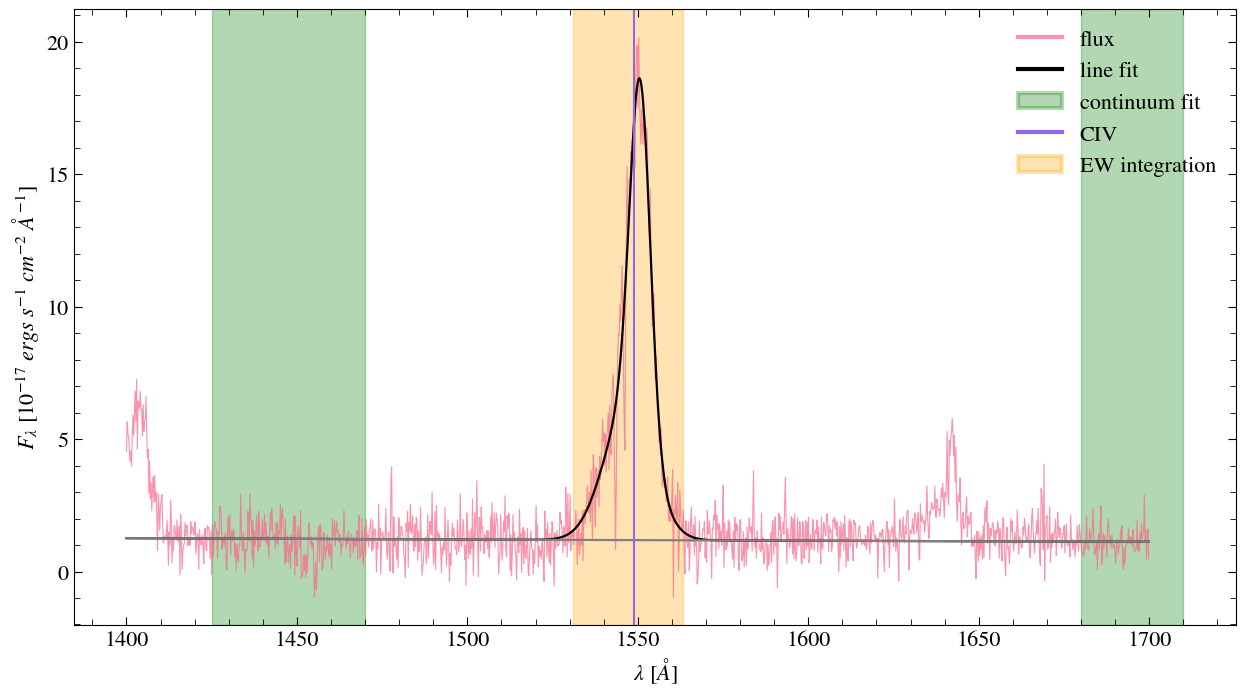


                SDSS: 233636.99+065231.0
                FWHM: 1647.445 vs 1483.559 (Hamann)
                REW: 155.856 vs 128.271 (Hamann) vs 154.853 (fit area)
                kt80: 0.292 vs 0.258 (Hamann)
    
---------------------------------------
---------------------------------------


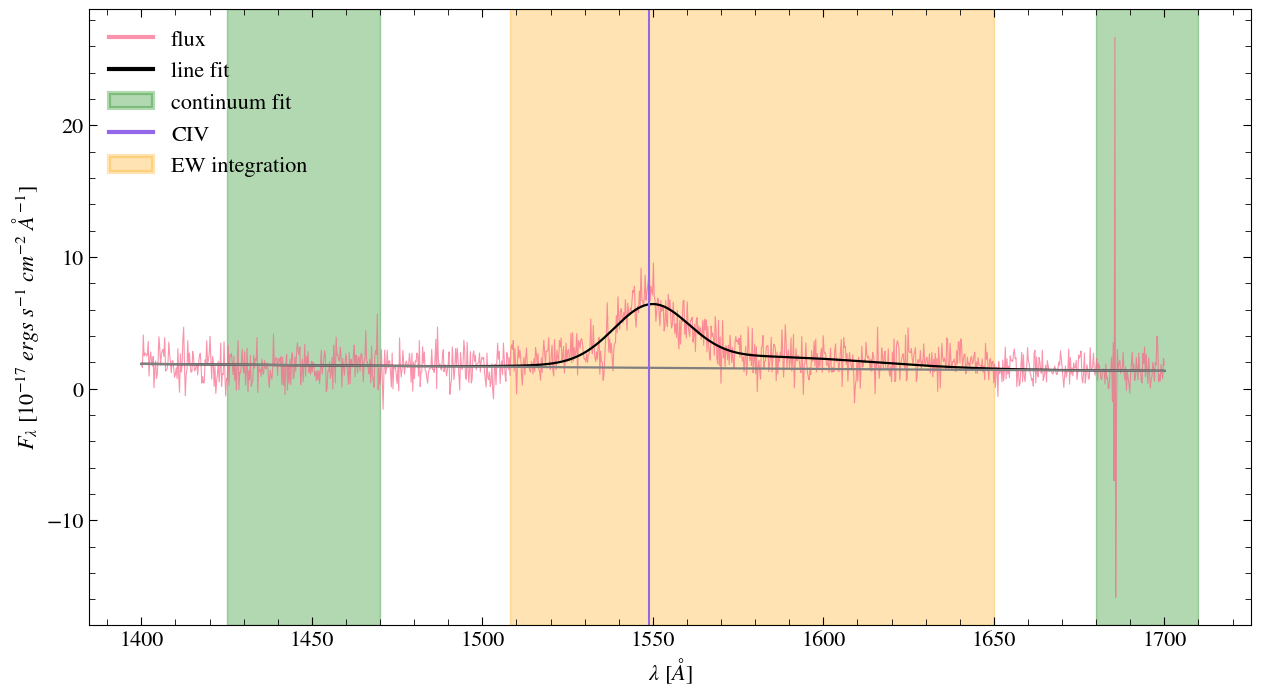


                SDSS: 082649.30+163945.2
                FWHM: 5480.556 vs 5633.199 (Hamann)
                REW: 131.52 vs 204.888 (Hamann) vs 121.915 (fit area)
                kt80: 0.299 vs 0.33 (Hamann)
    
---------------------------------------
---------------------------------------


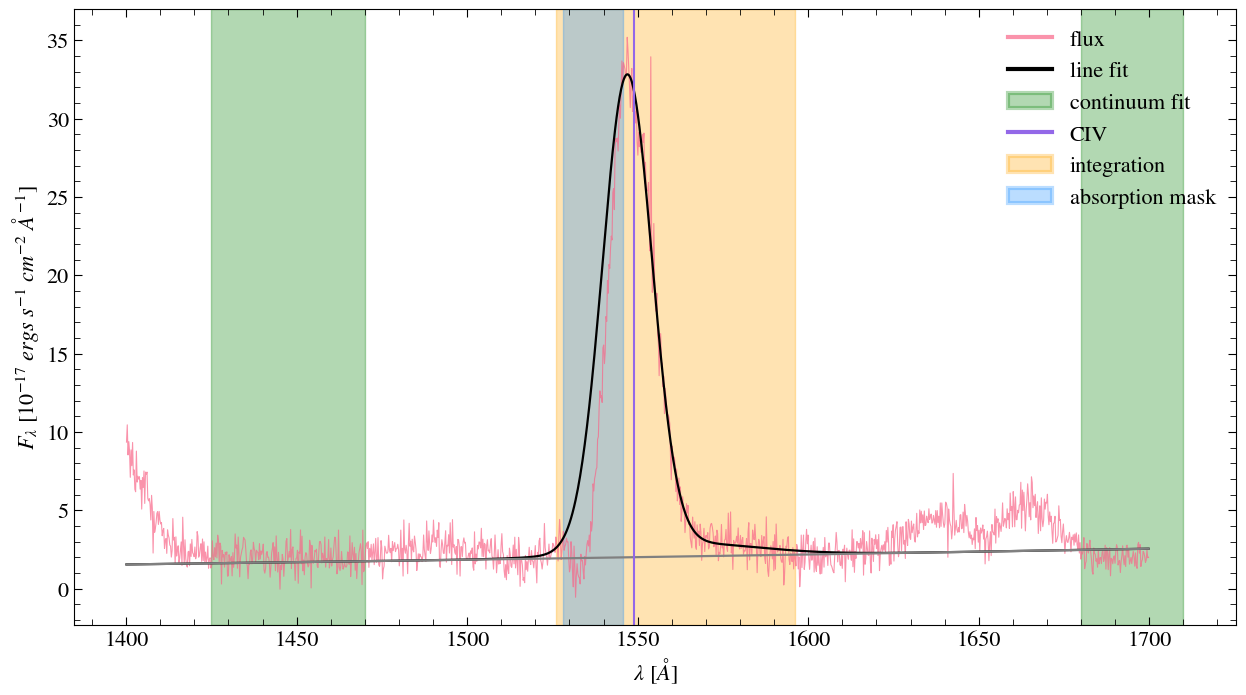


                SDSS: 083448.48+015921.1
                FWHM: 3352.608 vs 2863.092 (Hamann)
                REW: 250.8 vs 209.44 (Hamann) vs 294.222 (fit area)
                kt80: 0.368 vs 0.365 (Hamann)
    
---------------------------------------
---------------------------------------


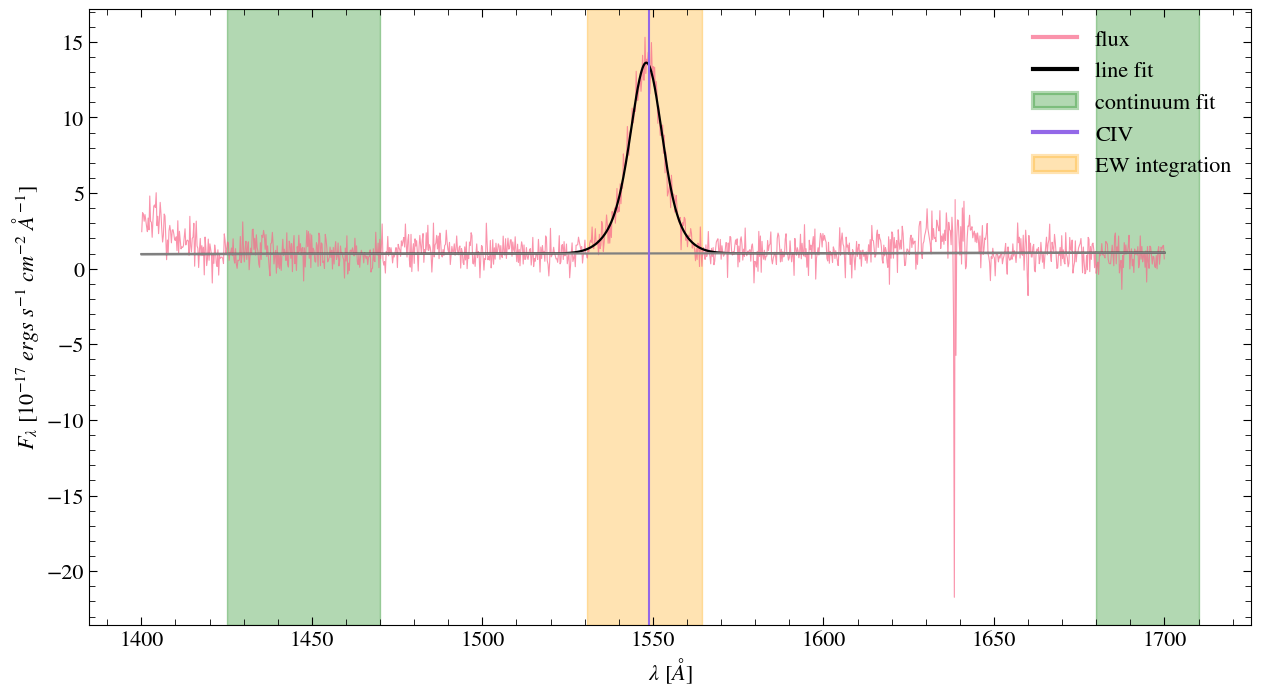


                SDSS: 131722.85+322207.5
                FWHM: 2204.986 vs 2310.771 (Hamann)
                REW: 160.219 vs 159.85 (Hamann) vs 159.902 (fit area)
                kt80: 0.338 vs 0.36 (Hamann)
    
---------------------------------------
---------------------------------------


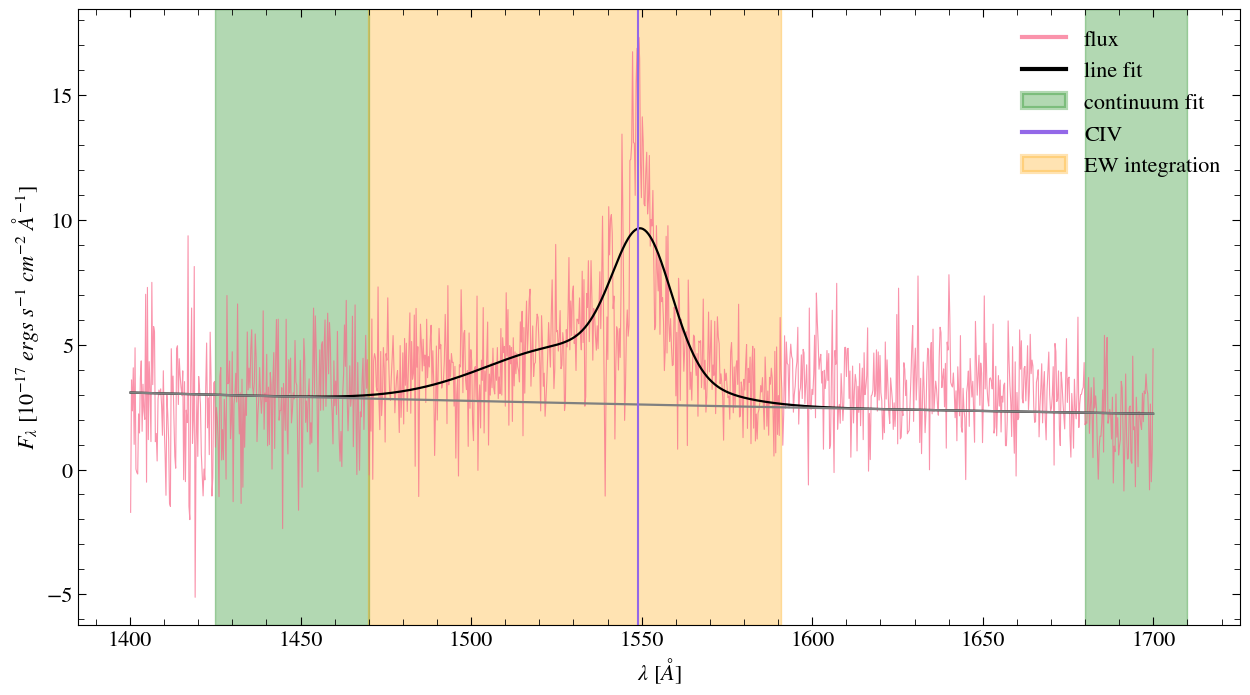


                SDSS: 082536.31+200040.3
                FWHM: 4860.689 vs 3265.175 (Hamann)
                REW: 105.307 vs 210.805 (Hamann) vs 98.222 (fit area)
                kt80: 0.212 vs 0.171 (Hamann)
    
---------------------------------------
---------------------------------------


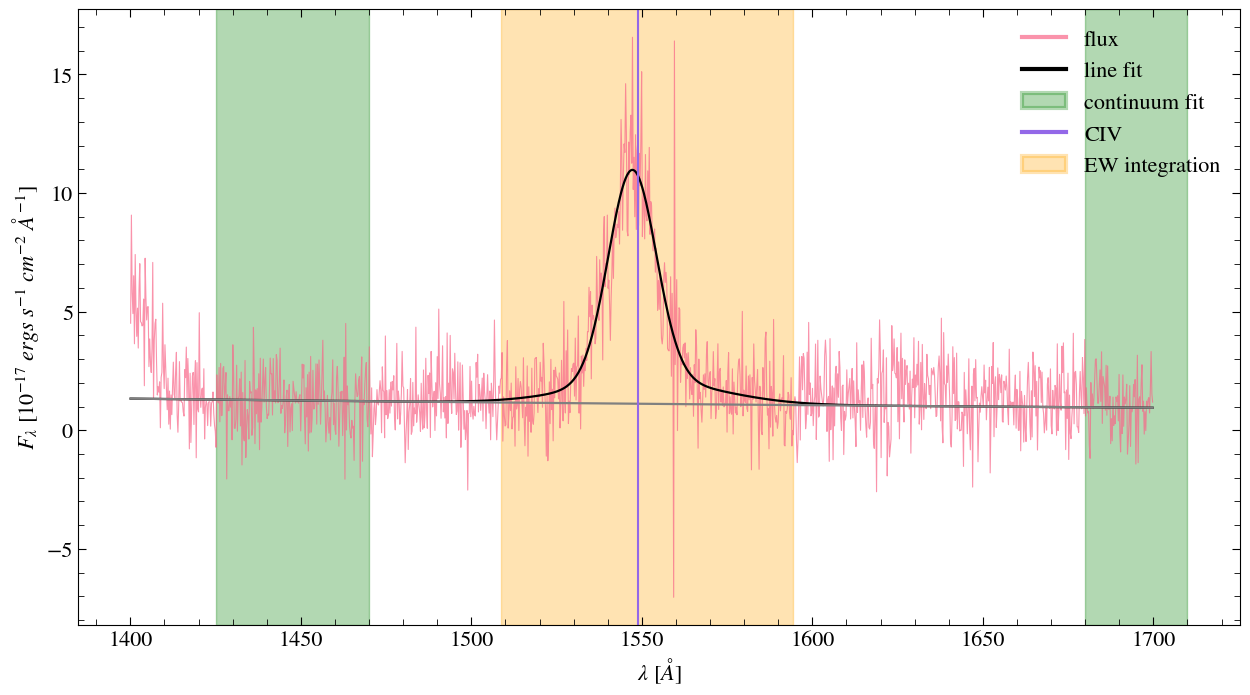


                SDSS: 130936.14+560111.3
                FWHM: 3388.208 vs 3629.606 (Hamann)
                REW: 179.221 vs 160.873 (Hamann) vs 182.871 (fit area)
                kt80: 0.351 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


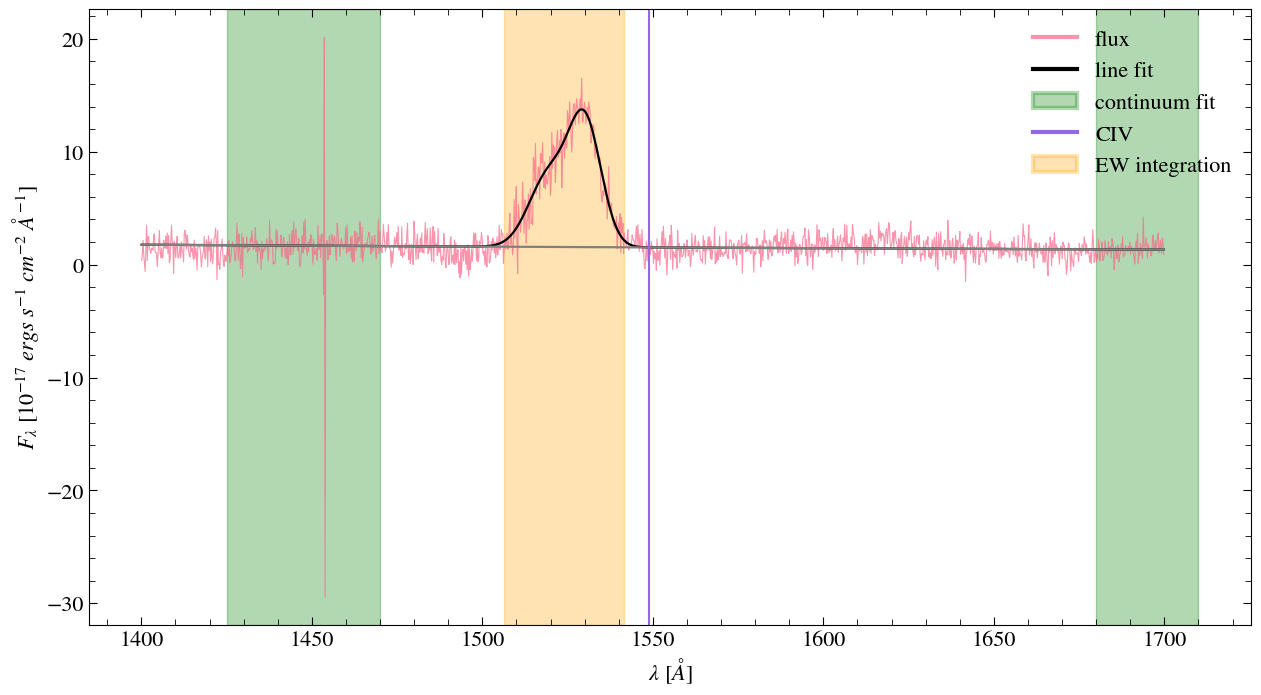


                SDSS: 002400.25+245031.9
                FWHM: 3513.603 vs 3523.282 (Hamann)
                REW: 140.807 vs 143.69 (Hamann) vs 140.994 (fit area)
                kt80: 0.307 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


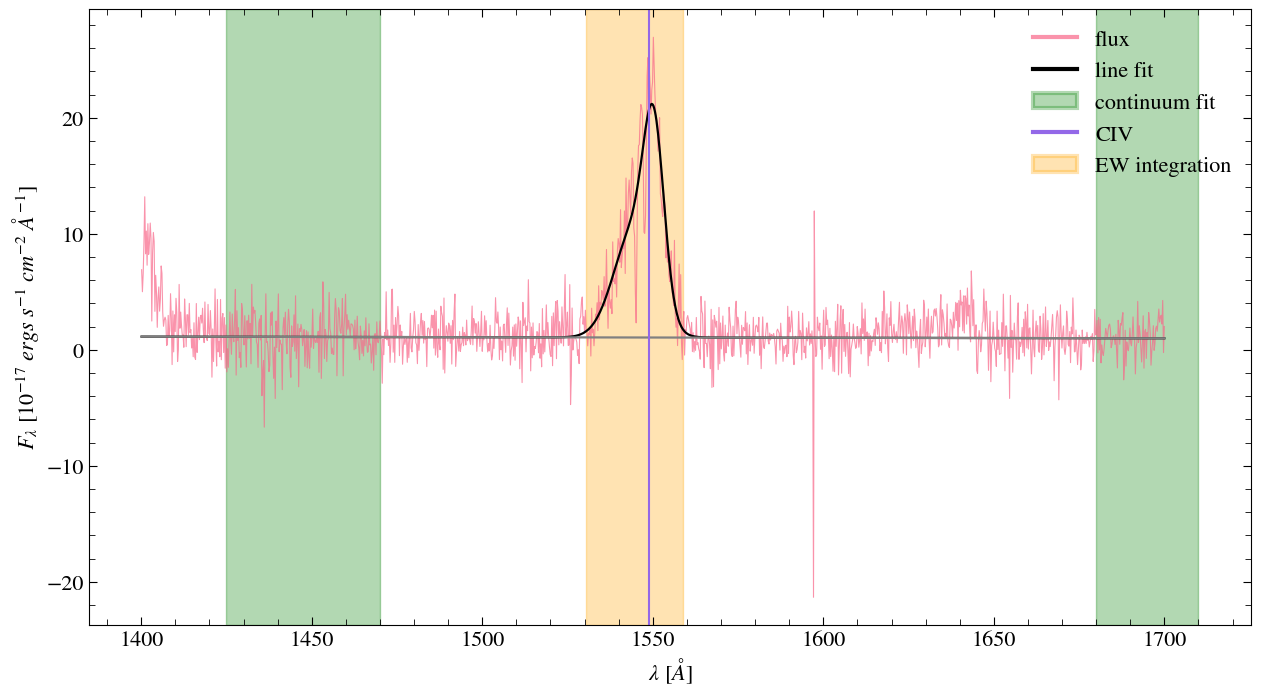


                SDSS: 134026.99+083427.2
                FWHM: 2003.591 vs 2075.846 (Hamann)
                REW: 227.762 vs 357.973 (Hamann) vs 227.31 (fit area)
                kt80: 0.266 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


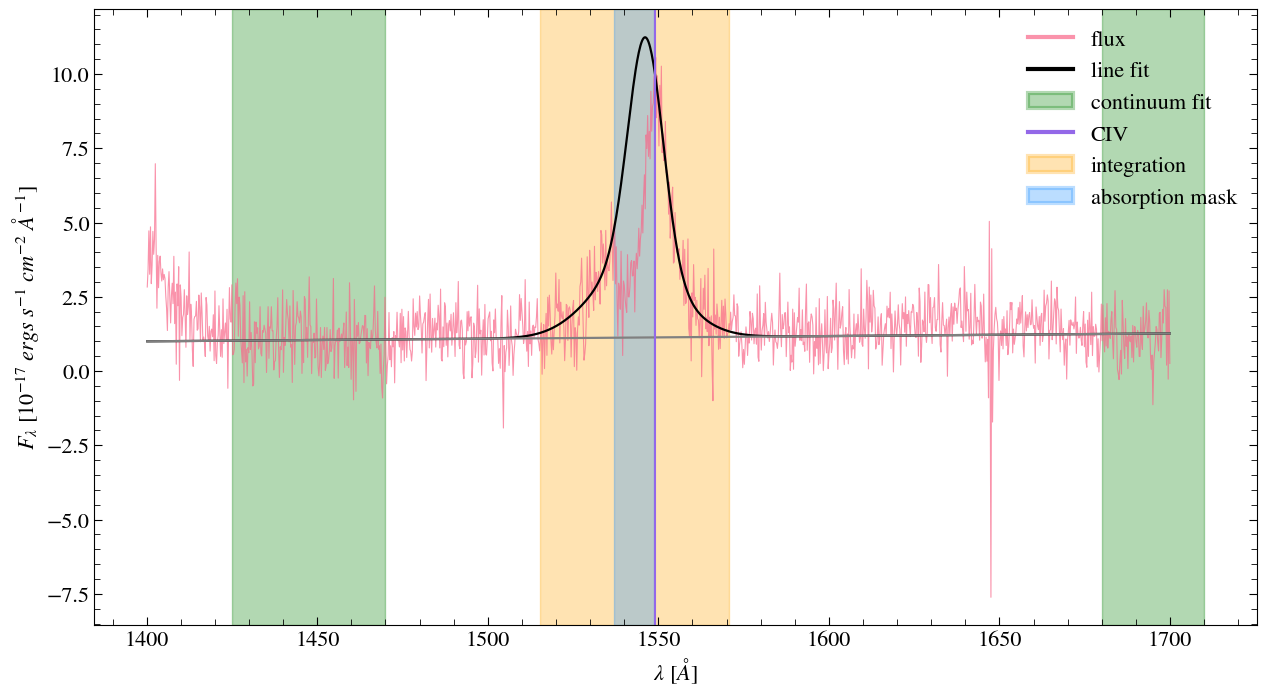


                SDSS: 134001.90+322155.9
                FWHM: 2714.37 vs 1822.703 (Hamann)
                REW: 105.622 vs 130.709 (Hamann) vs 152.623 (fit area)
                kt80: 0.318 vs 0.207 (Hamann)
    
---------------------------------------
---------------------------------------


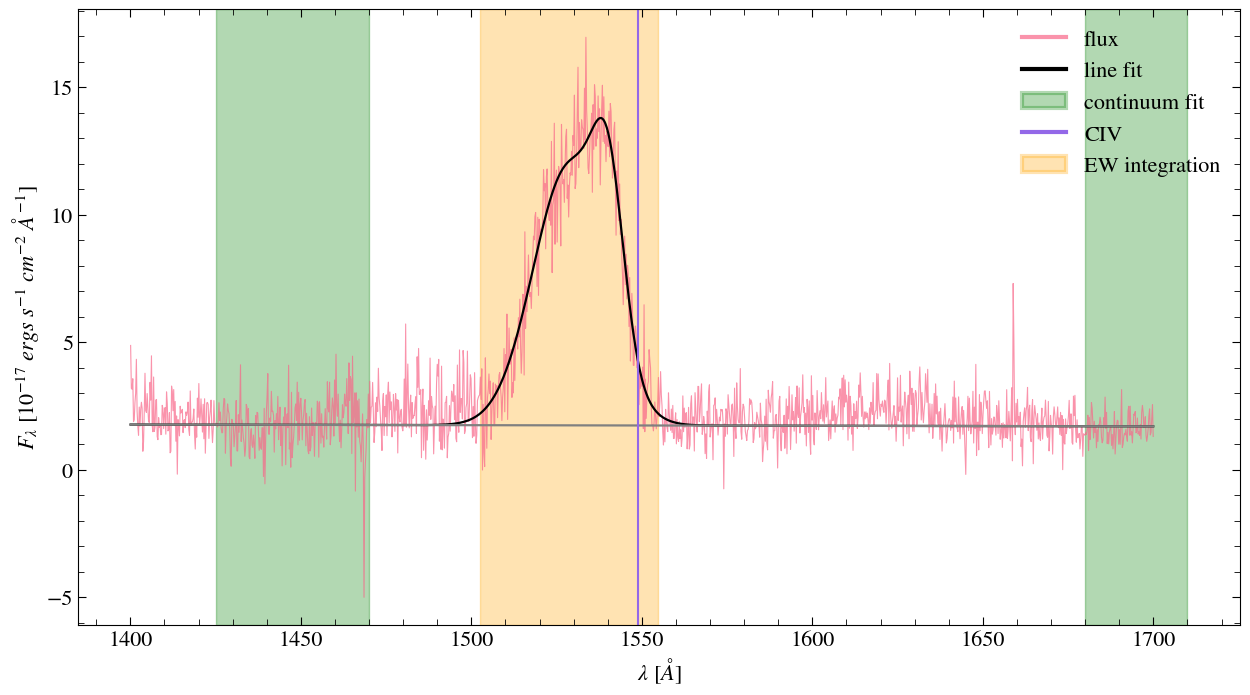


                SDSS: 104611.50+024351.6
                FWHM: 5297.934 vs 4854.269 (Hamann)
                REW: 188.683 vs 217.582 (Hamann) vs 189.252 (fit area)
                kt80: 0.448 vs 0.354 (Hamann)
    
---------------------------------------
---------------------------------------


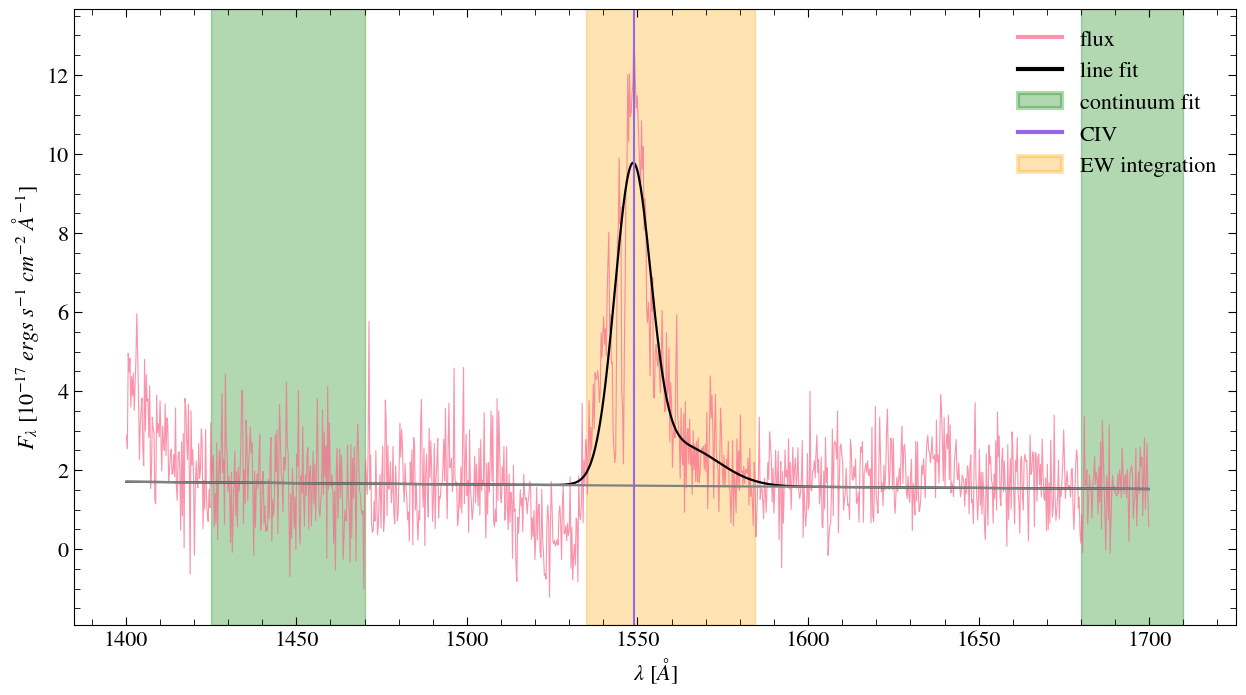


                SDSS: 093506.96-024137.7
                FWHM: 2519.208 vs 2404.04 (Hamann)
                REW: 82.148 vs 119.496 (Hamann) vs 79.724 (fit area)
                kt80: 0.345 vs 0.249 (Hamann)
    
---------------------------------------
---------------------------------------


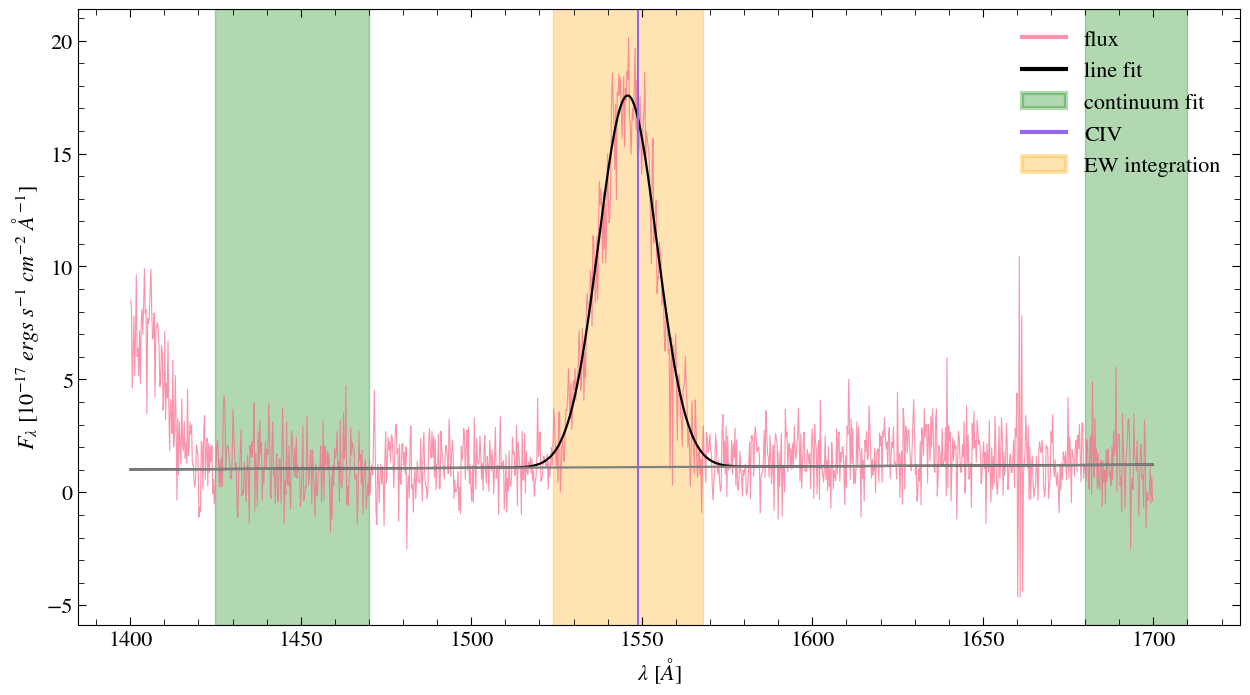


                SDSS: 232326.17-010033.1
                FWHM: 3884.838 vs 3989.27 (Hamann)
                REW: 312.072 vs 255.993 (Hamann) vs 311.642 (fit area)
                kt80: 0.372 vs 0.371 (Hamann)
    
---------------------------------------
---------------------------------------


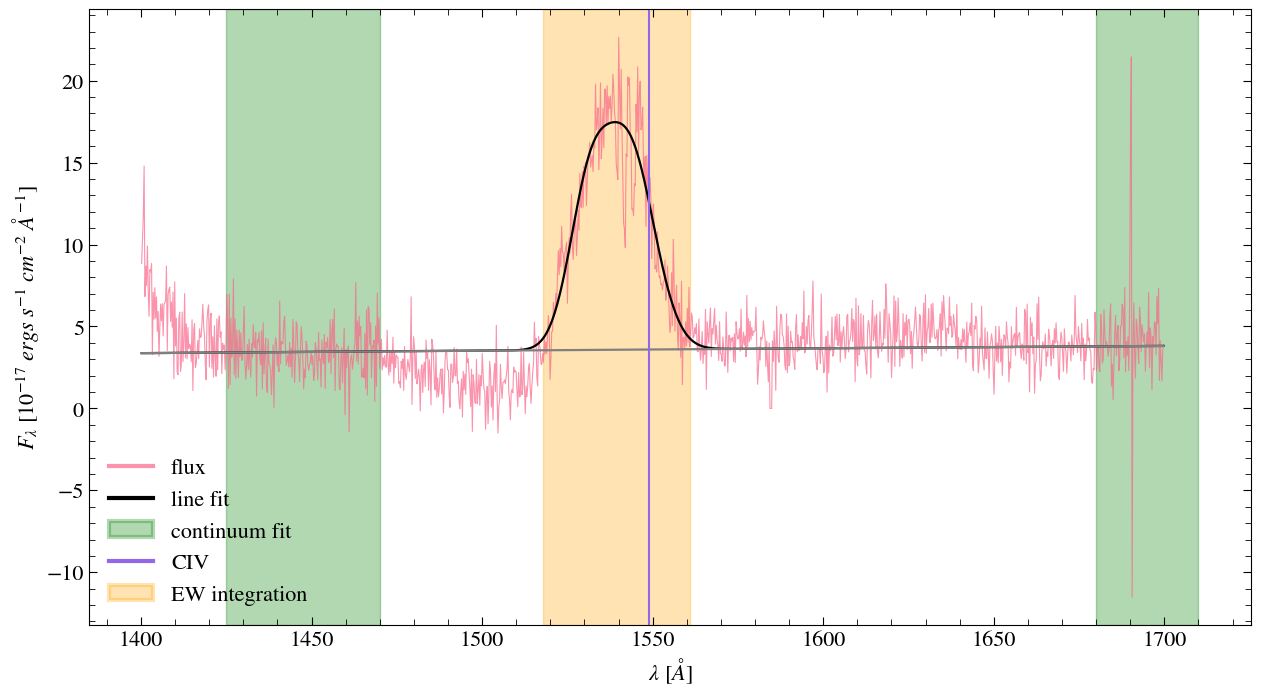


                SDSS: 103146.53+290324.1
                FWHM: 4778.987 vs 4363.774 (Hamann)
                REW: 97.21 vs 120.767 (Hamann) vs 96.881 (fit area)
                kt80: 0.483 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


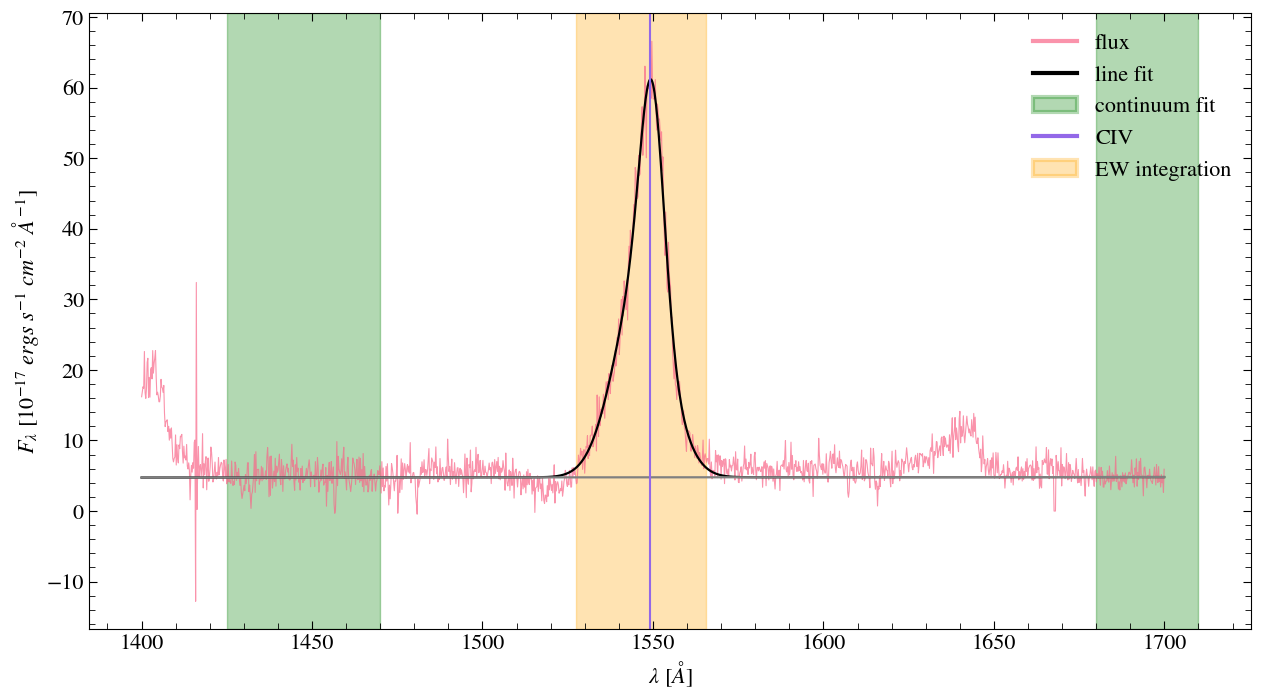


                SDSS: 165202.64+172852.3
                FWHM: 2305.291 vs 2403.322 (Hamann)
                REW: 167.792 vs 124.521 (Hamann) vs 167.255 (fit area)
                kt80: 0.28 vs 0.329 (Hamann)
    
---------------------------------------
---------------------------------------


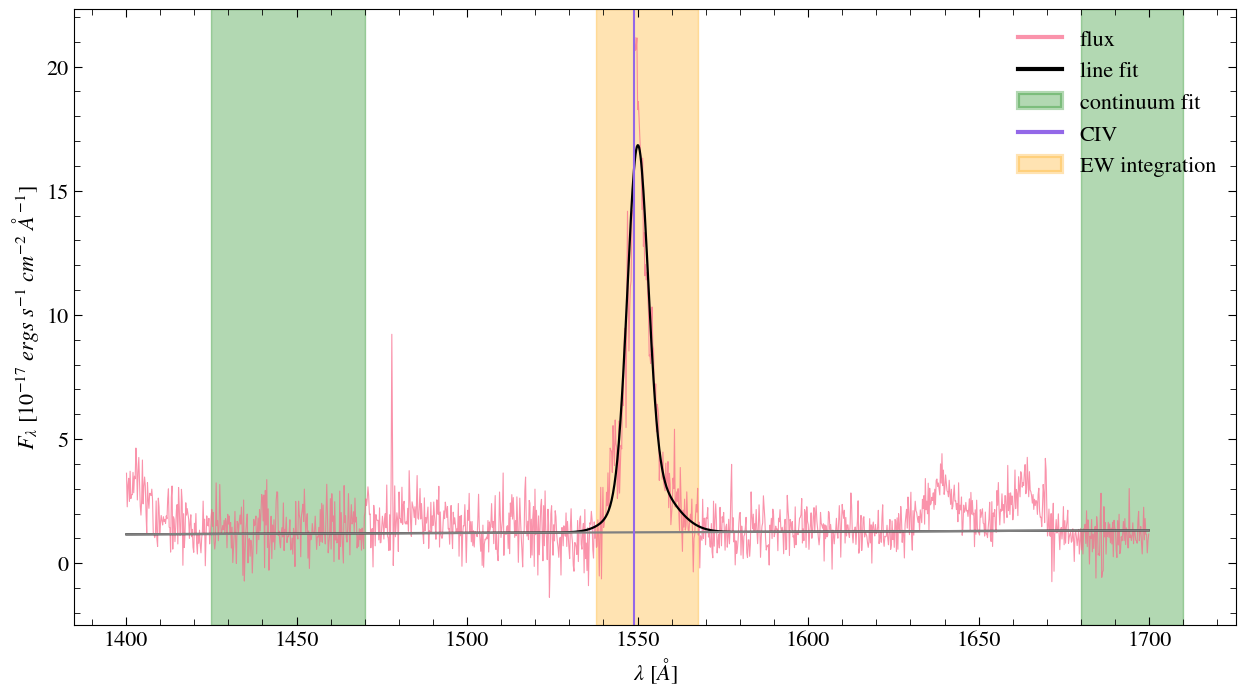


                SDSS: 122000.68+064045.3
                FWHM: 1483.674 vs 1047.131 (Hamann)
                REW: 113.474 vs 112.877 (Hamann) vs 111.853 (fit area)
                kt80: 0.345 vs 0.151 (Hamann)
    
---------------------------------------
---------------------------------------


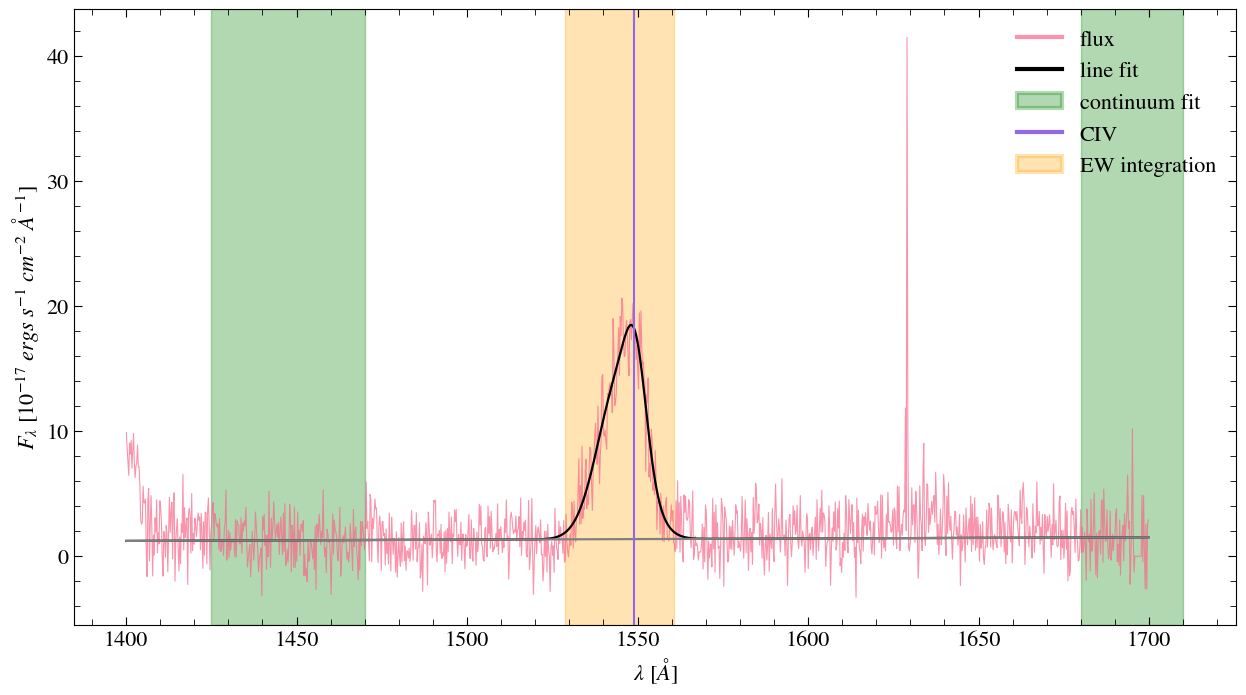


                SDSS: 121704.70+023417.1
                FWHM: 2730.448 vs 2603.968 (Hamann)
                REW: 184.557 vs 180.897 (Hamann) vs 184.648 (fit area)
                kt80: 0.338 vs 0.369 (Hamann)
    
---------------------------------------
---------------------------------------


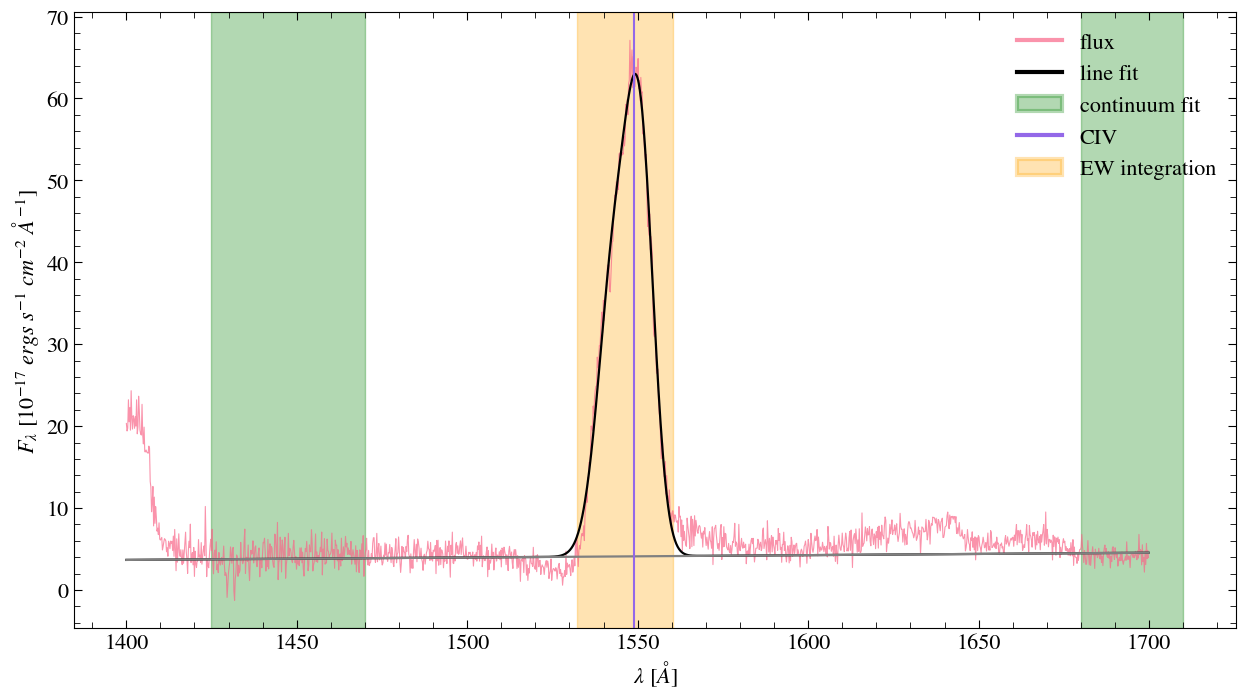


                SDSS: 131047.78+322518.3
                FWHM: 2864.782 vs 2793.839 (Hamann)
                REW: 213.71 vs 226.394 (Hamann) vs 213.93 (fit area)
                kt80: 0.381 vs 0.367 (Hamann)
    
---------------------------------------
---------------------------------------


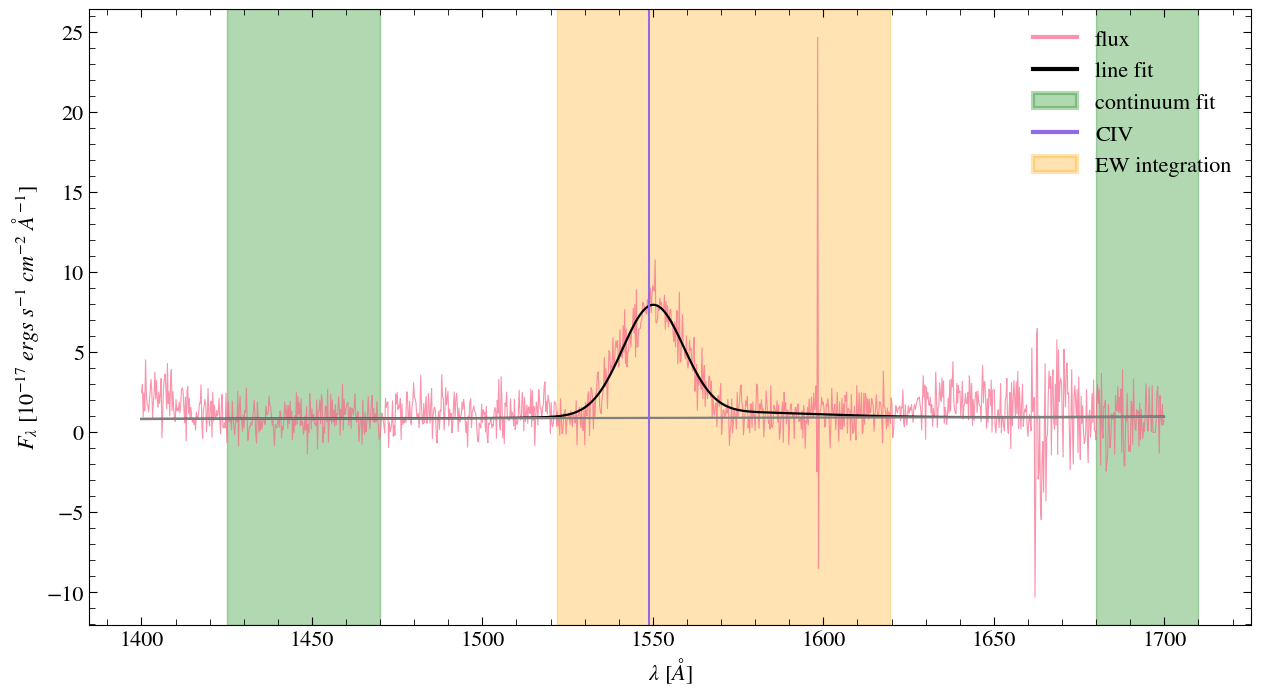


                SDSS: 221524.00-005643.8
                FWHM: 4181.825 vs 4280.102 (Hamann)
                REW: 191.834 vs 153.336 (Hamann) vs 192.91 (fit area)
                kt80: 0.363 vs 0.366 (Hamann)
    
---------------------------------------
---------------------------------------


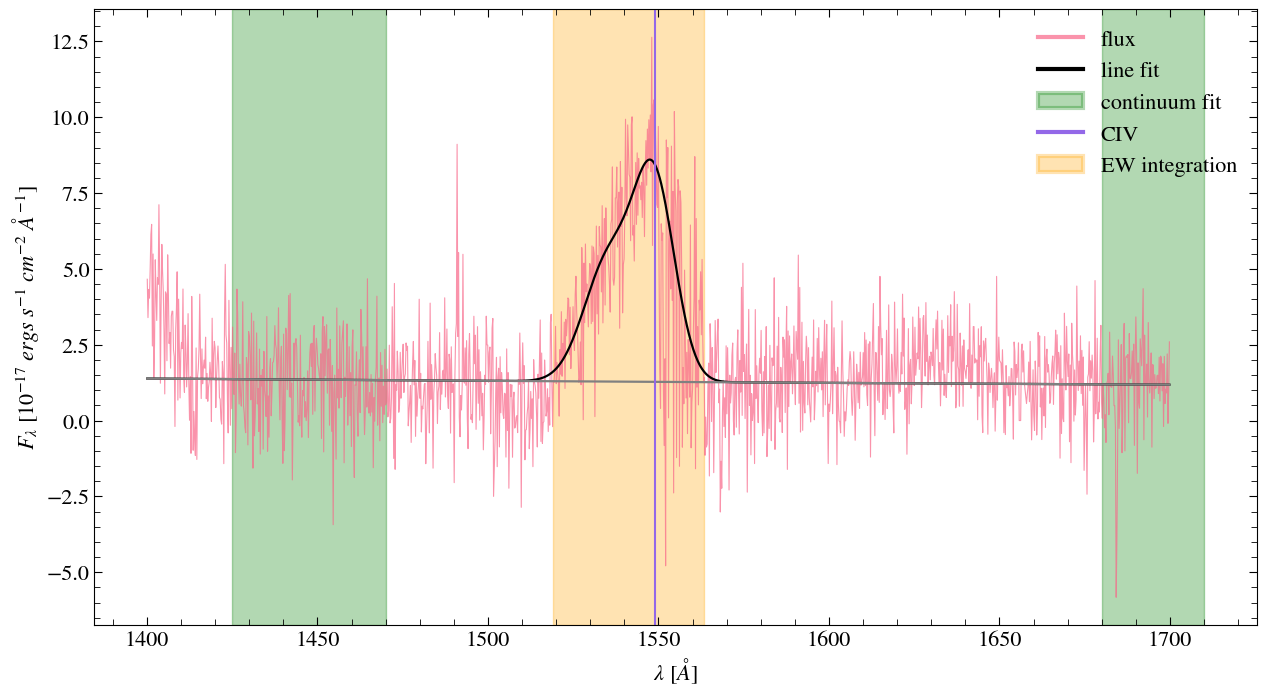


                SDSS: 134450.51+140139.2
                FWHM: 4519.205 vs 4487.034 (Hamann)
                REW: 127.696 vs 132.41 (Hamann) vs 131.353 (fit area)
                kt80: 0.315 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


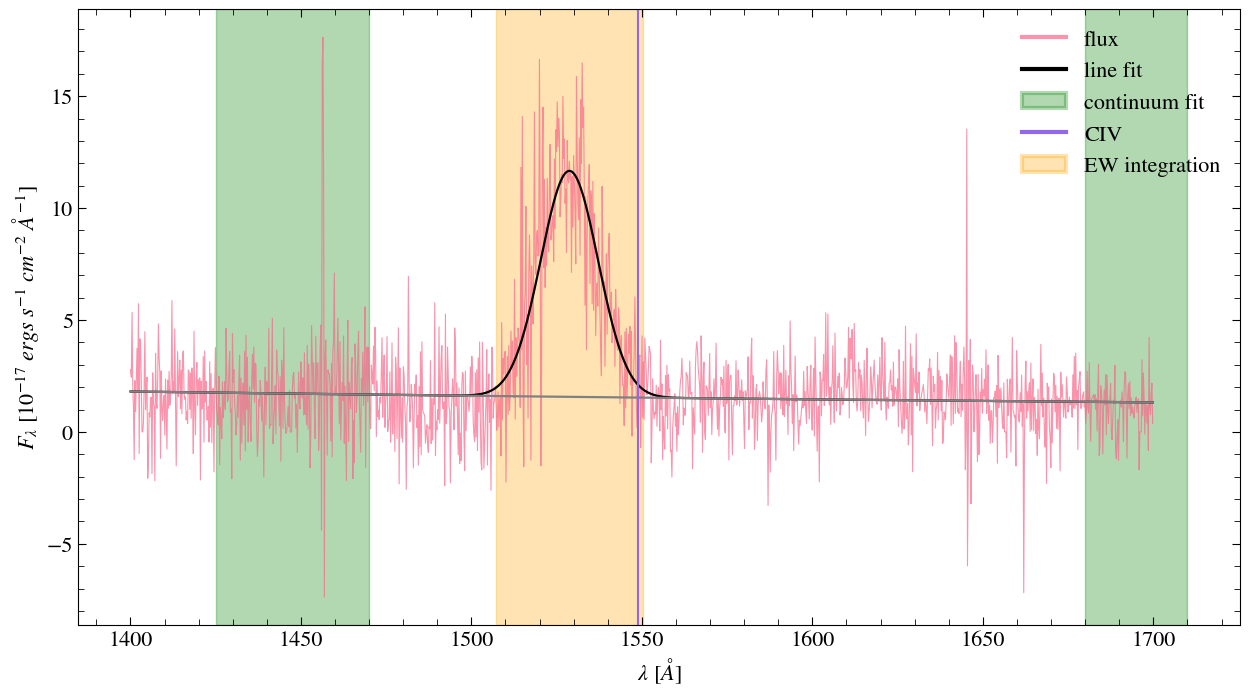


                SDSS: 153107.14+105825.8
                FWHM: 3823.334 vs 3936.554 (Hamann)
                REW: 138.767 vs 151.904 (Hamann) vs 134.296 (fit area)
                kt80: 0.372 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


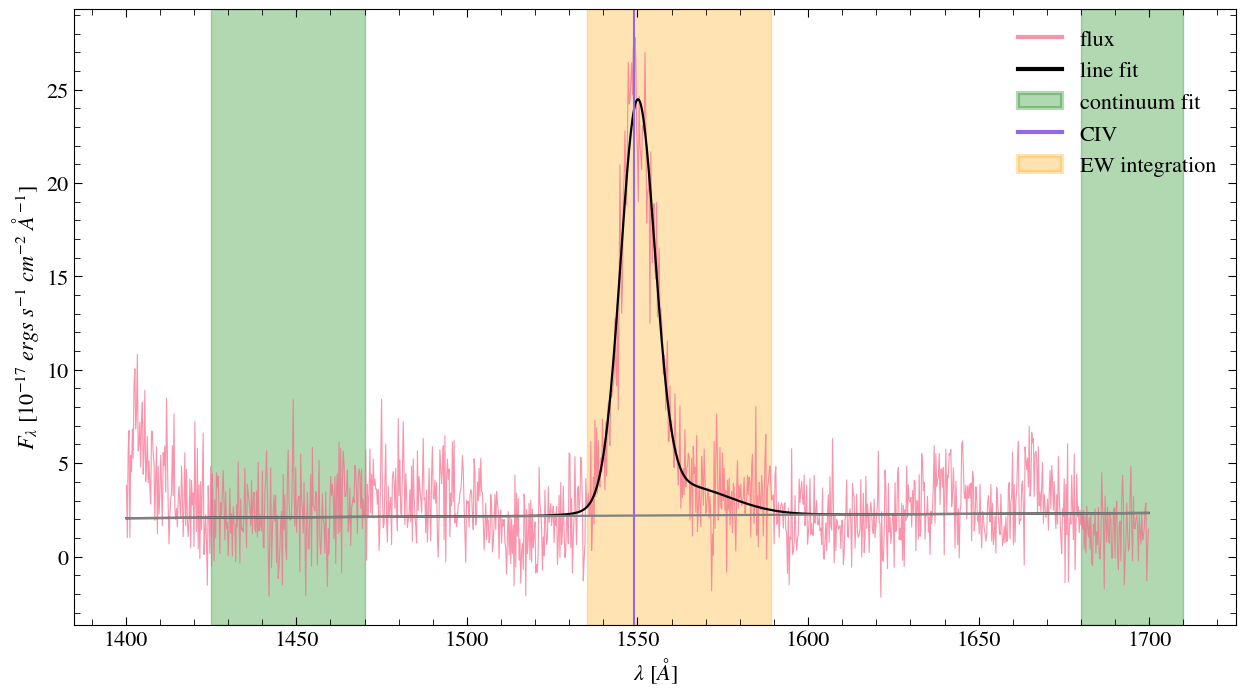


                SDSS: 104718.35+484433.8
                FWHM: 2364.521 vs 2521.46 (Hamann)
                REW: 147.348 vs 158.03 (Hamann) vs 145.13 (fit area)
                kt80: 0.359 vs 0.361 (Hamann)
    
---------------------------------------
---------------------------------------


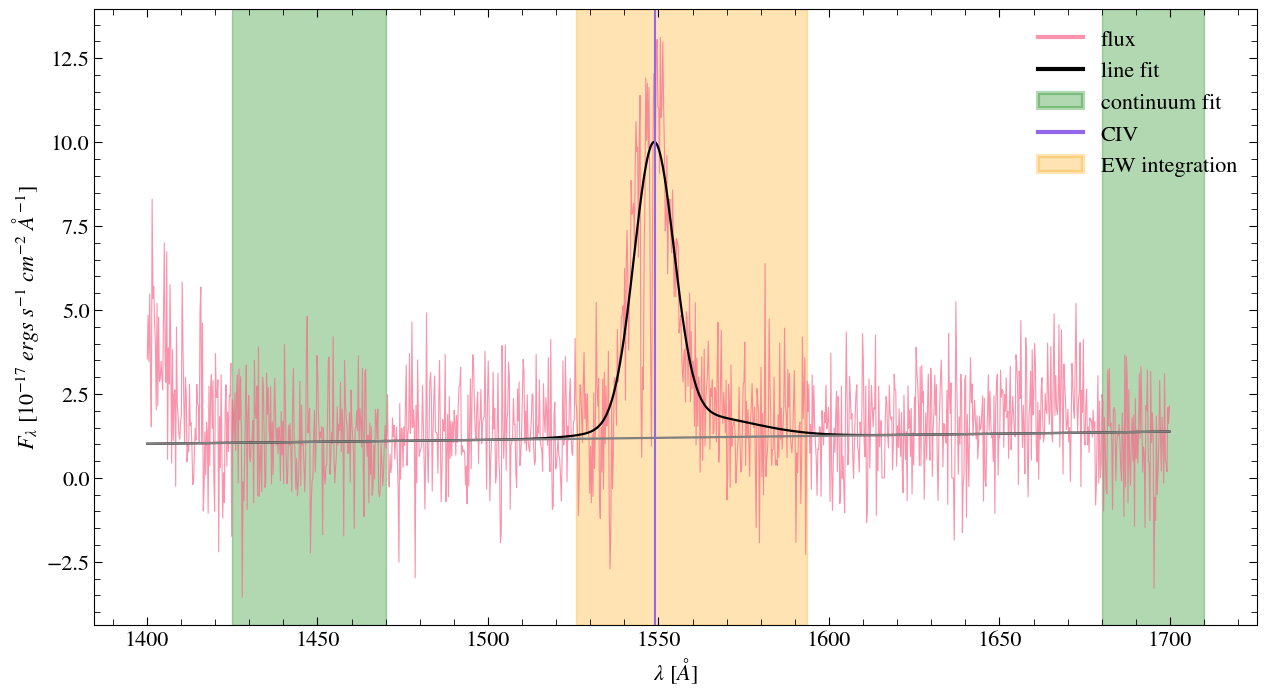


                SDSS: 020932.15+312202.7
                FWHM: 2766.997 vs 2180.064 (Hamann)
                REW: 124.214 vs 107.677 (Hamann) vs 123.998 (fit area)
                kt80: 0.357 vs 0.345 (Hamann)
    
---------------------------------------
---------------------------------------


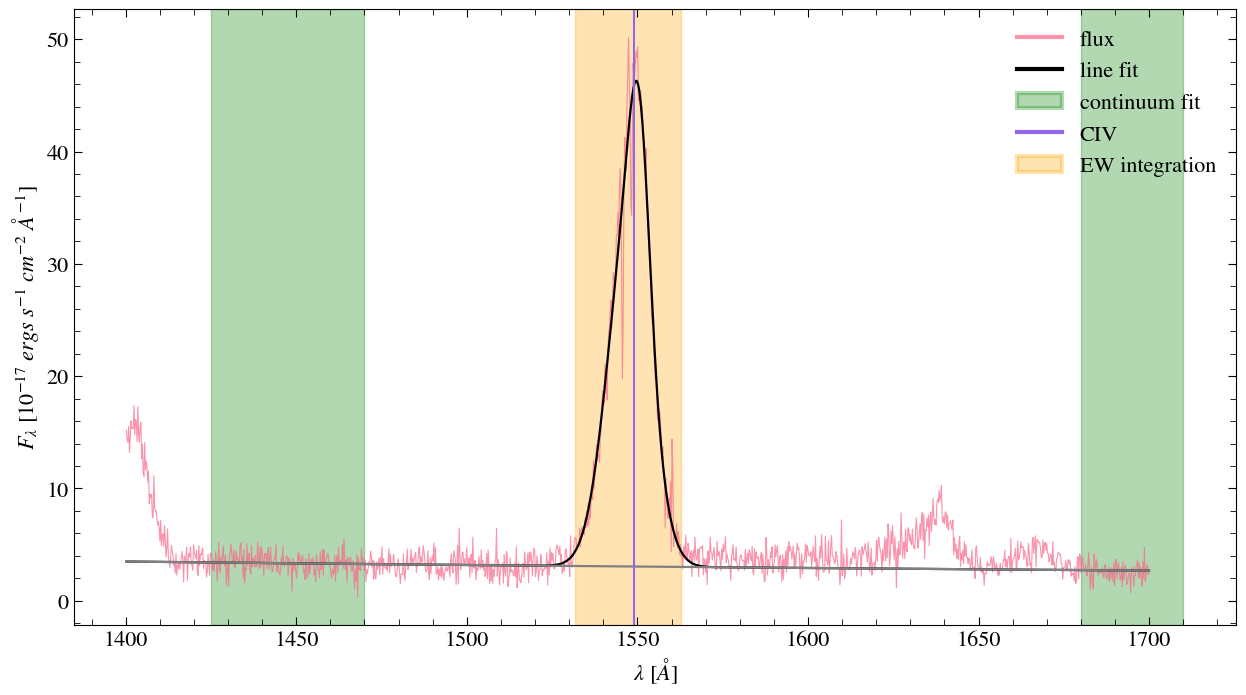


                SDSS: 082653.42+054247.3
                FWHM: 2383.29 vs 2433.822 (Hamann)
                REW: 190.769 vs 204.619 (Hamann) vs 189.638 (fit area)
                kt80: 0.313 vs 0.358 (Hamann)
    
---------------------------------------
---------------------------------------
ValueError in get_absorption_interval()


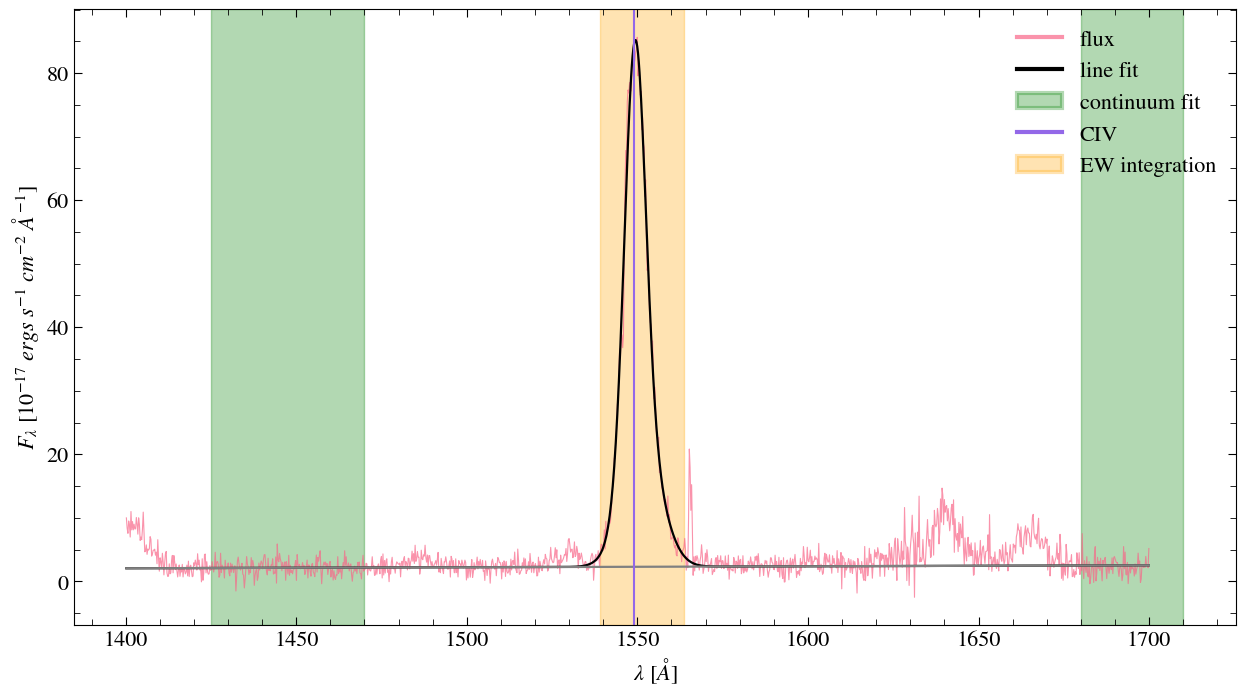


                SDSS: 232828.47+044346.8
                FWHM: 1566.719 vs 1583.693 (Hamann)
                REW: 328.162 vs 358.596 (Hamann) vs 328.325 (fit area)
                kt80: 0.342 vs 0.352 (Hamann)
    
---------------------------------------
---------------------------------------


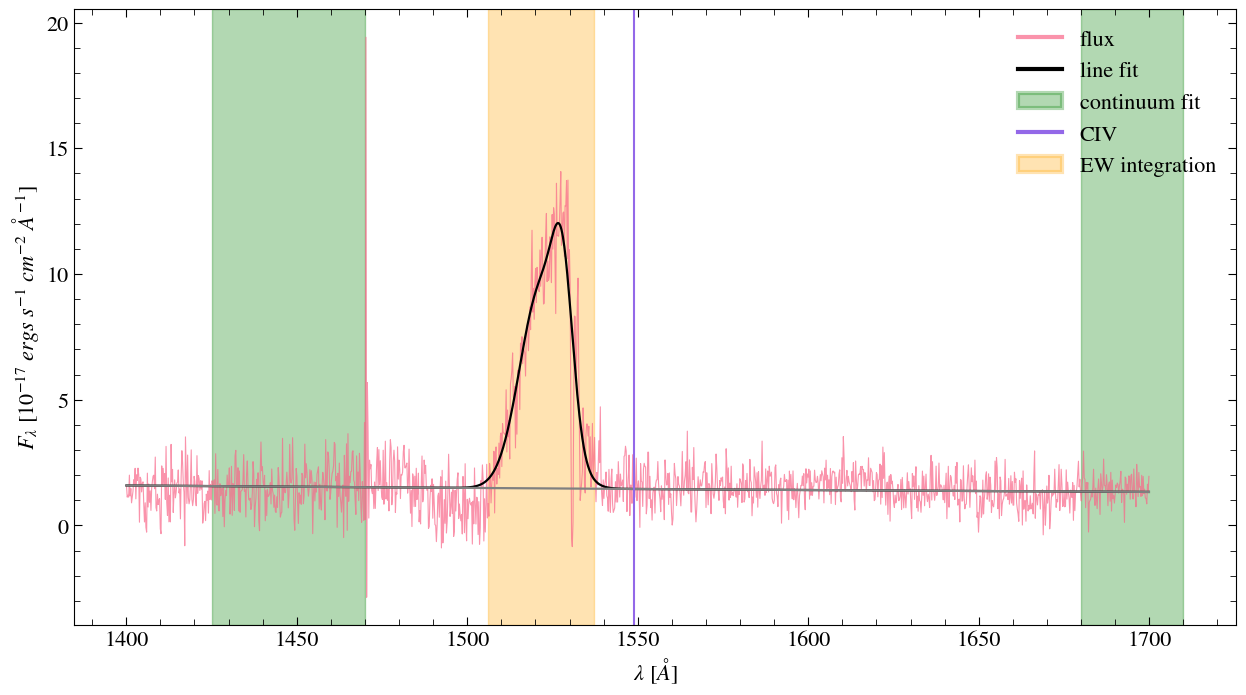


                SDSS: 154831.92+311951.4
                FWHM: 2959.912 vs 3050.048 (Hamann)
                REW: 110.375 vs 127.184 (Hamann) vs 110.127 (fit area)
                kt80: 0.353 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


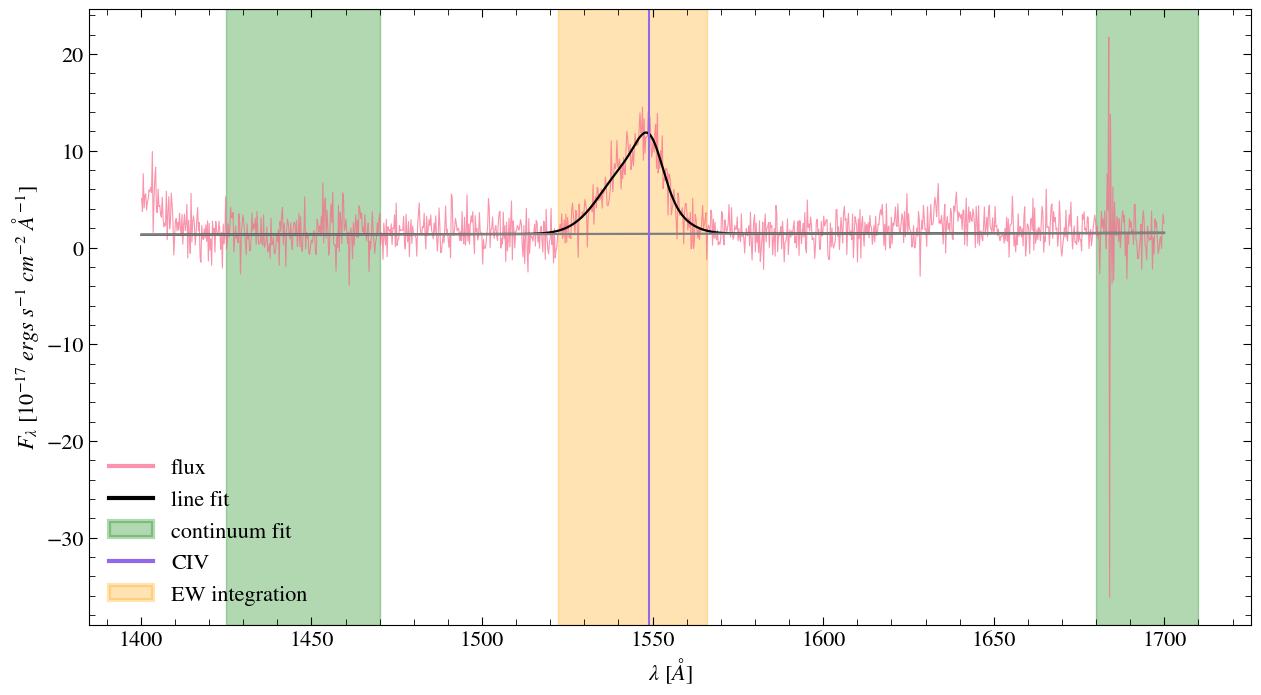


                SDSS: 080547.66+454159.0
                FWHM: 3349.701 vs 2667.071 (Hamann)
                REW: 139.522 vs 108.69 (Hamann) vs 138.15 (fit area)
                kt80: 0.293 vs 0.211 (Hamann)
    
---------------------------------------
---------------------------------------


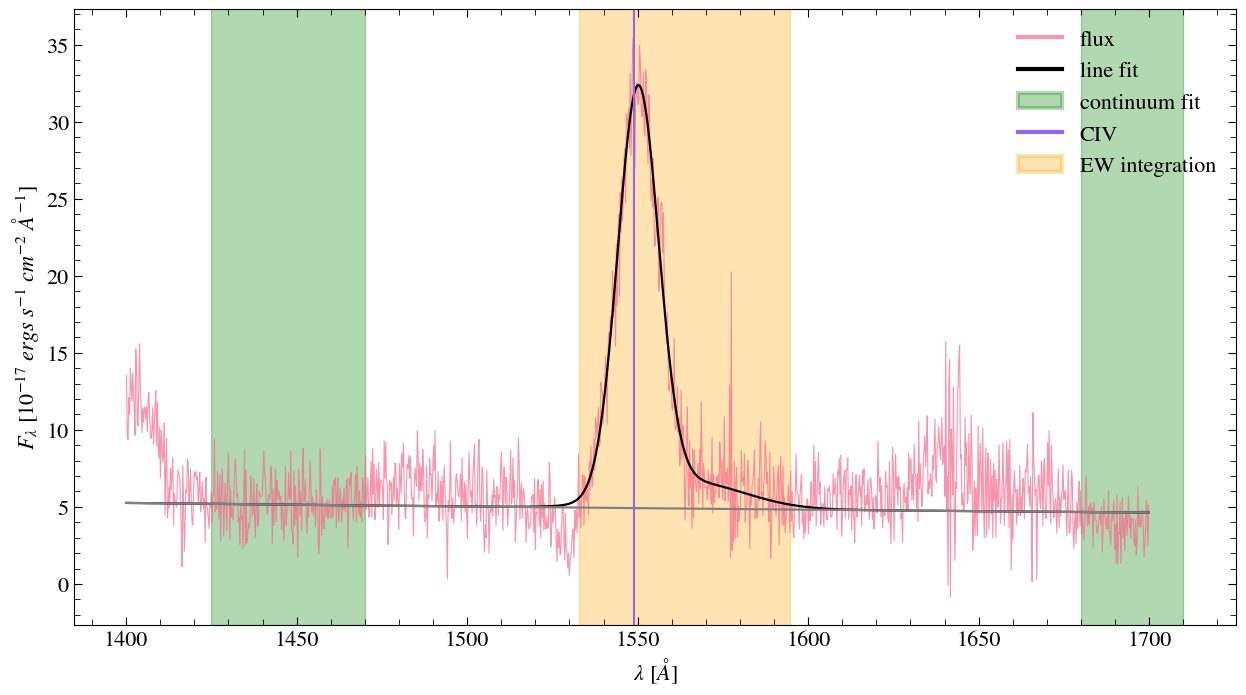


                SDSS: 014111.13-031852.5
                FWHM: 2808.48 vs 2985.648 (Hamann)
                REW: 93.997 vs 101.008 (Hamann) vs 93.56 (fit area)
                kt80: 0.361 vs 0.372 (Hamann)
    
---------------------------------------
---------------------------------------


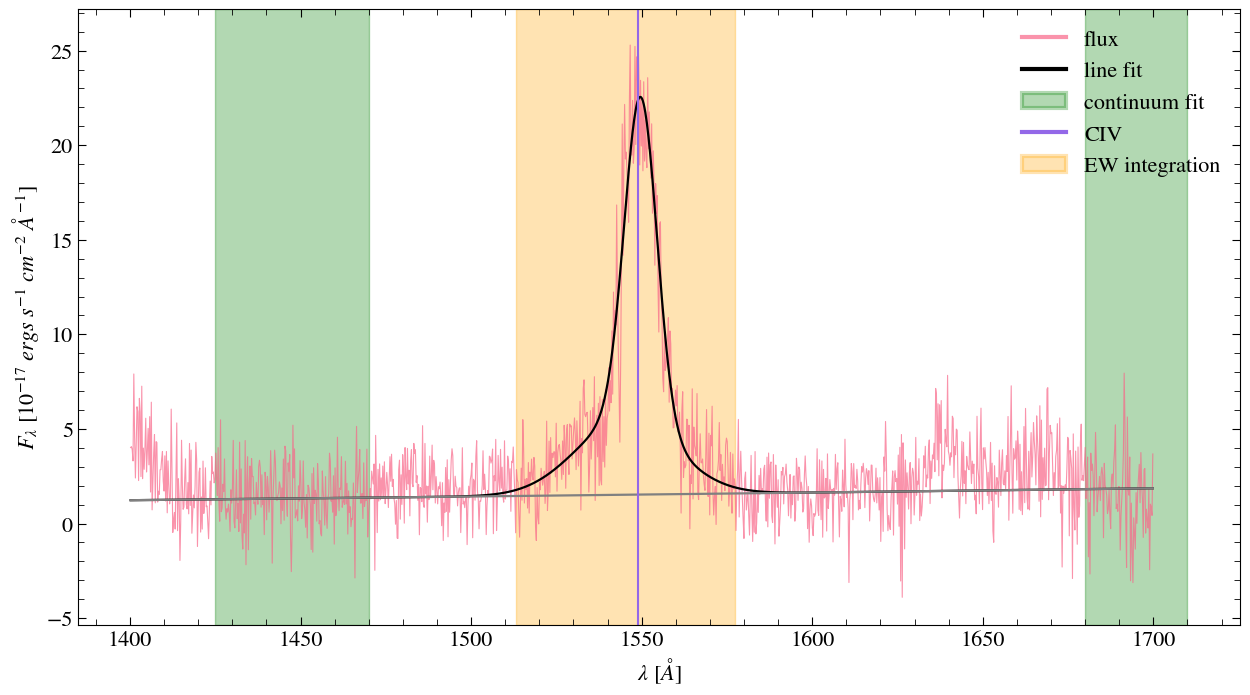


                SDSS: 000746.19+122223.9
                FWHM: 2470.697 vs 2432.83 (Hamann)
                REW: 231.478 vs 219.634 (Hamann) vs 226.07 (fit area)
                kt80: 0.319 vs 0.284 (Hamann)
    
---------------------------------------
---------------------------------------


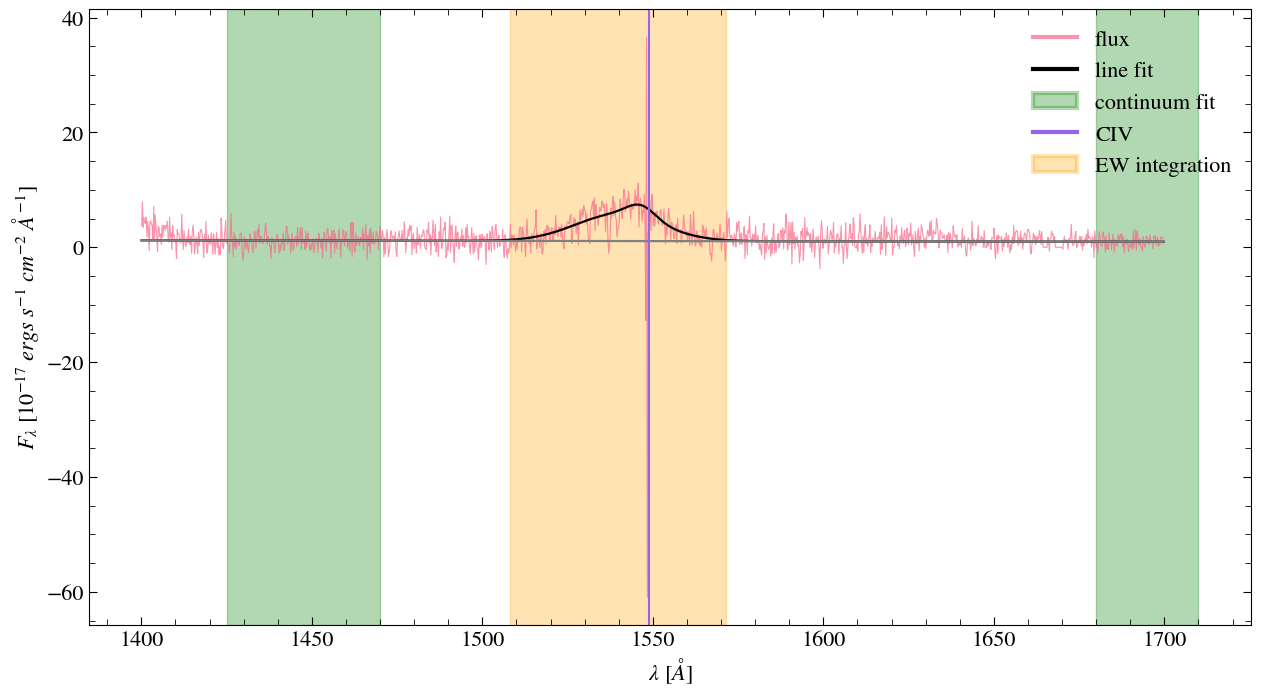


                SDSS: 085451.11+173009.1
                FWHM: 4764.633 vs 4199.357 (Hamann)
                REW: 150.669 vs 120.014 (Hamann) vs 155.441 (fit area)
                kt80: 0.266 vs 0.37 (Hamann)
    
---------------------------------------
---------------------------------------


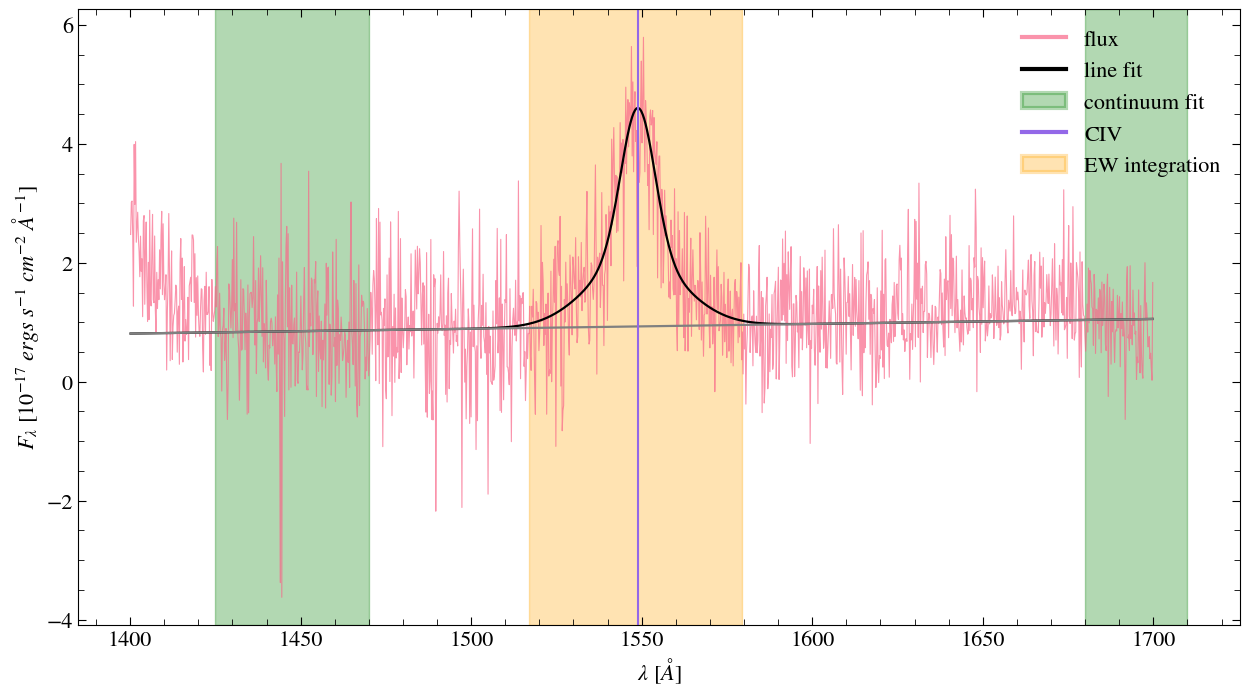


                SDSS: 102447.32-013633.8
                FWHM: 2817.938 vs 2843.202 (Hamann)
                REW: 74.19 vs 192.349 (Hamann) vs 74.061 (fit area)
                kt80: 0.286 vs 0.148 (Hamann)
    


In [11]:
for i in range(len(data)):
    if data["sdss_name"][i] in valid_sdss_names:
        print("---------------------------------------\n---------------------------------------")
        sanity_tests(i)

In [12]:
stats = data[data["my_rew"].notnull()][['sdss_name','redshift', 'rew', 'fit_rew', 'fwhm', 'kt80', 'my_fwhm', 'my_rew', 'my_kt80']]

stats["rew_abs_diff"] = stats["my_rew"] - stats["rew"]
stats["fwhm_abs_diff"] = stats["my_fwhm"] - stats["fwhm"]
stats["kt80_abs_diff"] = stats["my_kt80"] - stats["kt80"]

stats["rew_rel_diff"] = stats["rew_abs_diff"] / stats["rew"]
stats["fwhm_rel_diff"] = stats["fwhm_abs_diff"] / stats["fwhm"] 
stats["kt80_rel_diff"] = stats["kt80_abs_diff"] / stats["kt80"]

stats

,sdss_name,redshift,rew,fit_rew,fwhm,kt80,my_fwhm,my_rew,my_kt80,rew_abs_diff,fwhm_abs_diff,kt80_abs_diff,rew_rel_diff,fwhm_rel_diff,kt80_rel_diff
0,233636.99+065231.0,2.775400,128.270560,154.85297,1483.558675,0.258239,1647.444647,155.855677,0.292488,27.585117,163.885973,0.034249,0.215054,0.110468,0.132625
2,082649.30+163945.2,2.310120,204.888419,121.915097,5633.198558,0.329619,5480.555833,131.519804,0.299012,-73.368615,-152.642725,-0.030607,-0.358091,-0.027097,-0.092855
3,083448.48+015921.1,2.590582,209.439757,294.222329,2863.092351,0.364786,3352.607687,250.800132,0.367542,41.360375,489.515336,0.002757,0.197481,0.170974,0.007557
5,131722.85+322207.5,2.404809,159.849854,159.902438,2310.771010,0.359501,2204.985963,160.219285,0.338059,0.369431,-105.785047,-0.021443,0.002311,-0.045779,-0.059646
6,082536.31+200040.3,2.088145,210.804566,98.22206,3265.174575,0.171451,4860.688755,105.306627,0.212006,-105.497939,1595.51418,0.040555,-0.500454,0.488646,0.236541
7,130936.14+560111.3,2.576908,160.872544,182.871225,3629.606223,0.360732,3388.208164,179.221368,0.350871,18.348824,-241.398059,-0.009861,0.114058,-0.066508,-0.027336
12,002400.25+245031.9,2.837482,143.689957,140.994404,3523.281699,0.372201,3513.603334,140.807213,0.30724,-2.882744,-9.678365,-0.064961,-0.020062,-0.002747,-0.174532
13,134026.99+083427.2,2.492270,357.973489,227.309838,2075.845539,0.345148,2003.591113,227.761521,0.266046,-130.211967,-72.254426,-0.079102,-0.363748,-0.034807,-0.229183
14,134001.90+322155.9,2.386438,130.708645,152.622541,1822.703397,0.207409,2714.369673,105.621533,0.318358,-25.087111,891.666277,0.110949,-0.191932,0.4892,0.534928
16,104611.50+024351.6,2.799161,217.581636,189.252159,4854.268520,0.354079,5297.933725,188.683255,0.448205,-28.898381,443.665205,0.094125,-0.132816,0.091397,0.265831


In [14]:
current_stats_path = "data/local/desi_current_best_measurements.csv"

stats.to_csv(current_stats_path)